# Unsupervised Learning: PCA, NMF, t-SNE

## Conceptual Overview

- **PCA**: linear orthogonal projection maximizing variance (SVD solution).  
- **NMF**: non-negative low-rank factorization (alternating optimization).  
- **t-SNE**: nonlinear manifold embedding for visualization (local neighborhood preservation).

They all reduce dimensionality, but differ in:
- objective function, constraints, and optimization
- geometric interpretation (projection vs factorization vs neighborhood embedding)
- interpretability and intended use (modeling vs visualization)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

RANDOM_STATE = 0

def plot_image_grid(images, n_row=2, n_col=8, title=None, cmap="gray"):
    """Plot first n_row*n_col images (2D arrays) as a grid."""
    fig, axes = plt.subplots(n_row, n_col, figsize=(1.7*n_col, 1.7*n_row))
    axes = np.array(axes).reshape(-1)
    for ax, img in zip(axes, images[: n_row*n_col]):
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## 1. Data

X shape: (1797, 64)
y classes: [0 1 2 3 4 5 6 7 8 9]


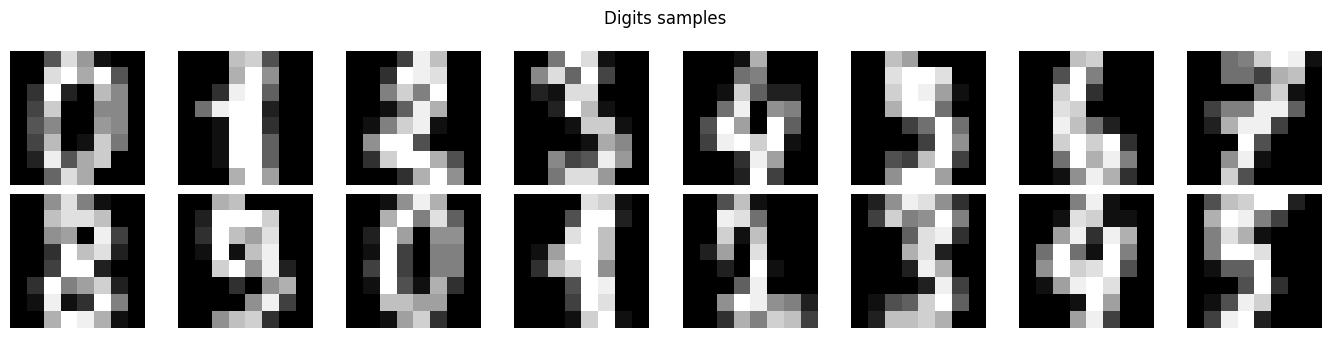

In [18]:
# Digits dataset
digits = load_digits()
X = digits.data          # (n_samples, 64)
y = digits.target        # for visualization only
images = digits.images   # (n_samples, 8, 8)

print("X shape:", X.shape)
print("y classes:", np.unique(y))

plot_image_grid(images, n_row=2, n_col=8, title="Digits samples")


# 2. PCA — Variance Maximization and Orthogonal Projection

## 2.1 Objective and geometry

For centered data matrix $X \in \mathbb{R}^{n\times p}$, PCA finds directions $v$ that maximize variance:

\begin{align*}
\max_{\|v\|=1} \mathrm{Var}(Xv)
\end{align*}


- `components_` (PCA): rows of $V$ (principal axes in feature space)  
- `fit_transform(X)` returns scores $Z$: coordinates of samples in PC space

## 2.2 API pattern: explicit vs pipeline

Textbook (explicit) style is good for learning.
Pipeline is safer for cross-validation / grid search (prevents leakage).


In [31]:
# PCA: explicit style
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z2 = pca2.fit_transform(X_scaled)

print("Z2 shape:", Z2.shape)


Z2 shape: (1797, 2)


In [32]:
# PCA: pipeline style 
pca2_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=RANDOM_STATE)
)
Z2_pipe = pca2_pipe.fit_transform(X)

# Should be identical up to numerical precision (and possible sign flips).
print("Max abs diff:", np.max(np.abs(Z2 - Z2_pipe)))


Max abs diff: 0.0


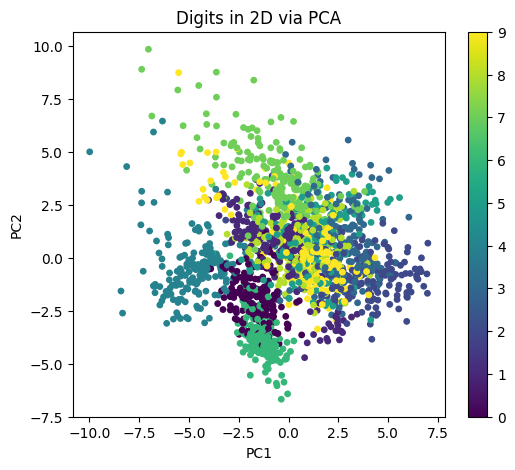

In [21]:
plt.figure(figsize=(6,5))
sc = plt.scatter(Z2_pipe[:, 0], Z2_pipe[:, 1], c=y, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits in 2D via PCA")
plt.colorbar(sc)
plt.show()


## 2.3 Choosing number of components (explained variance)

PCA provides `explained_variance_ratio_` = proportion of variance captured by each component.
We can choose the smallest $k$ such that cumulative variance ≥ threshold $\tau$.

We use `np.searchsorted` instead of `argmax` on a boolean array.


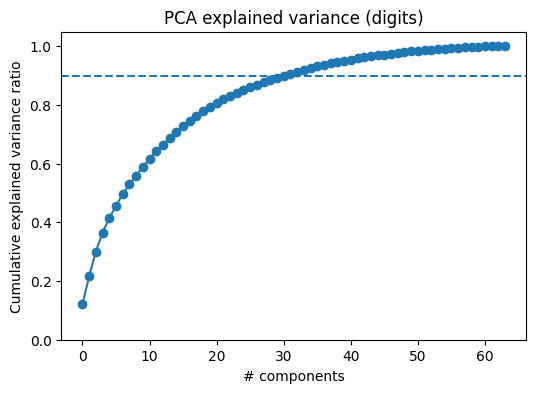

Smallest k with >=90% variance: 31


In [22]:
pca_full = make_pipeline(StandardScaler(), PCA(random_state=RANDOM_STATE))
pca_full.fit(X)
pca_model = pca_full.named_steps["pca"]

evr = pca_model.explained_variance_ratio_
cum_var = np.cumsum(evr)

plt.figure(figsize=(6,4))
plt.plot(cum_var, marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("# components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA explained variance (digits)")
plt.ylim(0, 1.05)
plt.show()

k_90 = np.searchsorted(cum_var, 0.90) + 1
print("Smallest k with >=90% variance:", k_90)


## 2.4 Reconstruction

With $k$ components, reconstruction is the orthogonal projection back to feature space:

\begin{align*}
\hat{X} = ZV
\end{align*}

We visualize how reconstruction quality changes when $k$ is selected by variance threshold.


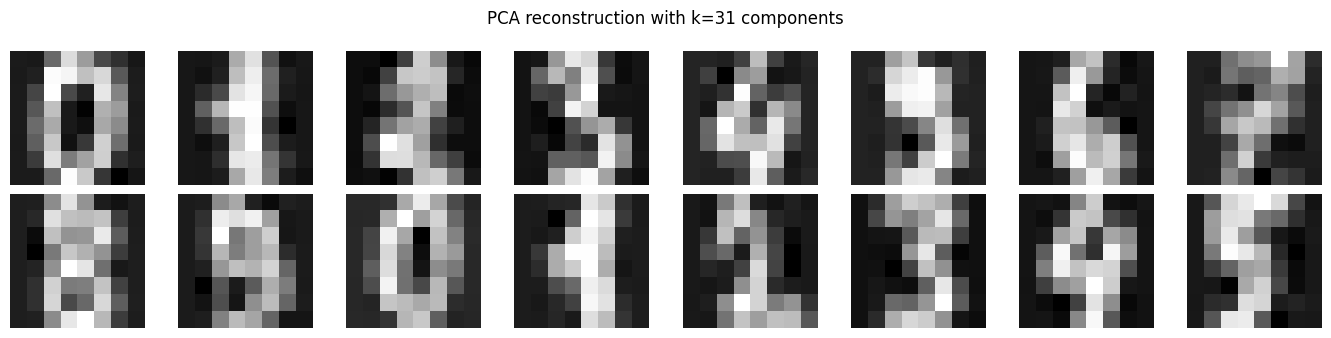

In [23]:
k = k_90
pca_k = make_pipeline(StandardScaler(), PCA(n_components=k, random_state=RANDOM_STATE))
Zk = pca_k.fit_transform(X)
X_rec = pca_k.inverse_transform(Zk)  # reconstruction in original feature scale

imgs_rec = X_rec.reshape(-1, 8, 8)
plot_image_grid(imgs_rec, n_row=2, n_col=8, title=f"PCA reconstruction with k={k} components")


# 3. NMF — Non-negative Matrix Factorization (parts-based)

## 3.1 Optimization view

Given **non-negative** data $X \ge 0$, NMF solves:

\begin{align*}
\min_{W,H \ge 0} \|X - WH\|_F^2
\end{align*}

- `components_` (NMF): \(H\) basis patterns (often interpretable “parts”)  
- `fit_transform(X)` returns \(W\): non-negative mixture weights per sample

**Key differences vs PCA**:
- no orthogonality constraint
- no closed-form SVD solution (non-convex; alternating optimization)
- solutions are not unique (rotations/scalings under constraints)

## 3.2 Practical note on scaling

Digits pixel intensities are already non-negative, but using `MinMaxScaler` is a robust habit when data may include negatives.


In [24]:
# NMF with pipeline (ensures non-negativity + makes inverse_transform include scaling inverse)
nmf_pipe = make_pipeline(
    MinMaxScaler(),
    NMF(n_components=16, init="nndsvda", random_state=RANDOM_STATE, max_iter=2000)
)

W = nmf_pipe.fit_transform(X)
nmf_model = nmf_pipe.named_steps["nmf"]

print("W shape:", W.shape)
print("H shape:", nmf_model.components_.shape)


W shape: (1797, 16)
H shape: (16, 64)


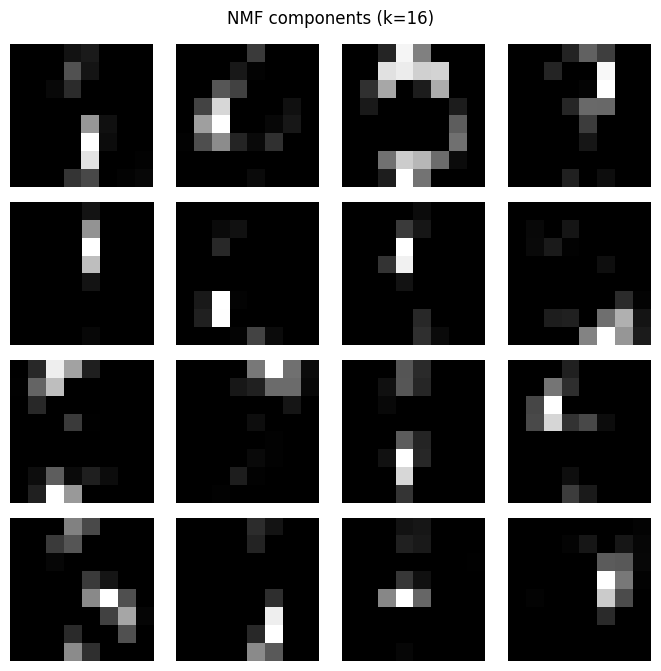

In [25]:
# Visualize NMF components (basis patterns)
H = nmf_model.components_
comp_imgs = H.reshape(-1, 8, 8)
plot_image_grid(comp_imgs, n_row=4, n_col=4, title="NMF components (k=16)")


## 3.3 Reconstruction: matrix multiplication interpretation

For pure NMF:

\begin{align*}
\hat{X} = WH

\end{align*}

In sklearn:
- `nmf.inverse_transform(W)` ≈ `W @ nmf.components_`

With a **Pipeline** including a scaler:
- pipeline `inverse_transform` also applies `scaler.inverse_transform(...)`.


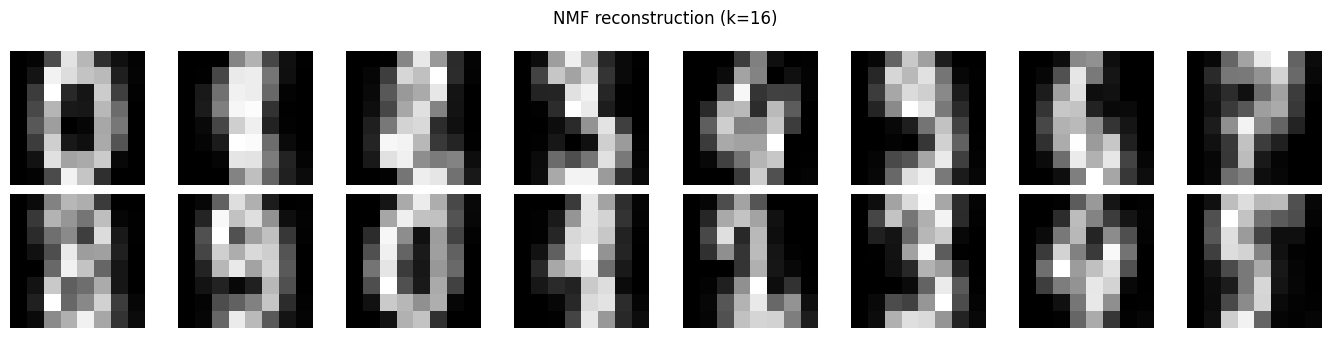

In [26]:
# Pipeline inverse_transform reconstruction
X_rec_nmf = nmf_pipe.inverse_transform(W)
imgs_rec_nmf = X_rec_nmf.reshape(-1, 8, 8)
plot_image_grid(imgs_rec_nmf, n_row=2, n_col=8, title="NMF reconstruction (k=16)")


In [27]:
# Verify the matrix-multiplication equivalence inside the pipeline (up to scaler inverse)
scaler = nmf_pipe.named_steps["minmaxscaler"]
H = nmf_model.components_
X_manual = scaler.inverse_transform(W @ H)

print("All close (manual vs pipeline inverse_transform):", np.allclose(X_manual, X_rec_nmf))


All close (manual vs pipeline inverse_transform): True


## 3.4 Choosing `n_components` in NMF

Unlike PCA, NMF does not provide explained variance.
Common strategies:
1. **Reconstruction error** curve (elbow)
2. **Interpretability** of components
3. **Downstream utility** (e.g., clustering/classification on W)

We inspect reconstruction error vs k (digits).


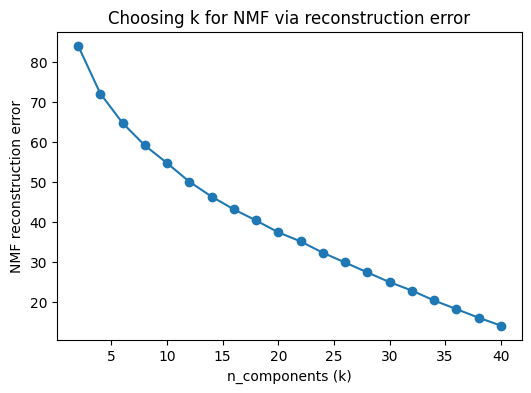

Look for an elbow + interpretability, not just smallest error.


In [28]:
# Reconstruction error vs k (elbow)
X_nonneg = MinMaxScaler().fit_transform(X)

ks = list(range(2, 41, 2))
errs = []
for k in ks:
    nmf = NMF(n_components=k, init="nndsvda", random_state=RANDOM_STATE, max_iter=2000)
    nmf.fit(X_nonneg)
    errs.append(nmf.reconstruction_err_)

plt.figure(figsize=(6,4))
plt.plot(ks, errs, marker="o")
plt.xlabel("n_components (k)")
plt.ylabel("NMF reconstruction error")
plt.title("Choosing k for NMF via reconstruction error")
plt.show()

best_k_note = "Look for an elbow + interpretability, not just smallest error."
print(best_k_note)


# 4. PCA vs NMF — Structural Comparison

| Property | PCA | NMF |
|---|---|---|
| Values allowed | ± | non-negative |
| Constraint | orthogonality | non-negativity |
| Geometry | projection / rotation | additive parts decomposition |
| Solution | closed-form (SVD) | iterative optimization |
| Uniqueness | essentially unique (sign) | non-unique |
| Interpretability | global modes | local parts |

**Mental model:**  
- PCA = rotate axes, keep top-k directions.  
- NMF = build each sample by adding non-negative “parts”.


# 5. t-SNE — Nonlinear Embedding for Visualization

t-SNE constructs pairwise similarities in high dimension and low dimension, then minimizes KL divergence between them.
It preserves **local neighborhoods** well, but does not preserve global distances.

Practical workflow: **PCA → t-SNE**
- PCA denoises and speeds up t-SNE
- For digits, using 50 PCs is common.

Important: t-SNE is typically for **visual inspection**, not as a feature extractor for downstream supervised modeling.


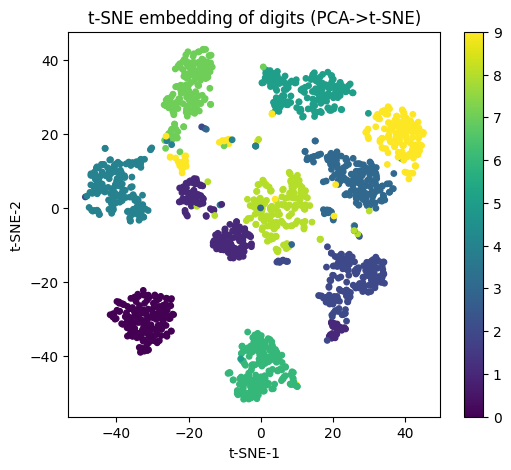

In [29]:
# PCA -> t-SNE (recommended workflow)
X_50 = make_pipeline(StandardScaler(), PCA(n_components=50, random_state=RANDOM_STATE)).fit_transform(X)

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    random_state=RANDOM_STATE
)
emb = tsne.fit_transform(X_50)

plt.figure(figsize=(6,5))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=y, s=15)
plt.title("t-SNE embedding of digits (PCA->t-SNE)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.colorbar(sc)
plt.show()


## 5.1 Sensitivity check: perplexity

t-SNE can change noticeably with perplexity and random seed.
We do a small sensitivity check.


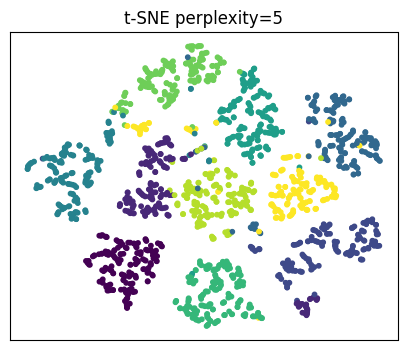

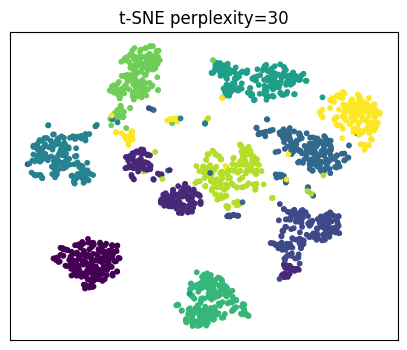

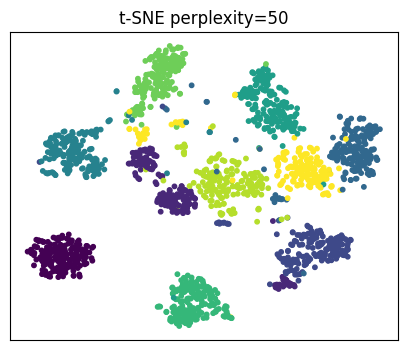

In [30]:
perps = [5, 30, 50]
for p in perps:
    tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=p, random_state=RANDOM_STATE)
    emb_p = tsne.fit_transform(X_50)

    plt.figure(figsize=(5,4))
    plt.scatter(emb_p[:, 0], emb_p[:, 1], c=y, s=10)
    plt.title(f"t-SNE perplexity={p}")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# 6. Practical Takeaways

- **PCA** is best seen as orthogonal projection; choose k via explained variance and validate via reconstruction.  
- **NMF** is low-rank *additive* decomposition; choose k via error + interpretability.  
- **t-SNE** is for visualization; interpret local neighborhoods, not global geometry.

## Reflection

Dimensionality reduction is not only compression; it imposes structural assumptions:

- PCA → orthogonality (linear subspace)  
- NMF → non-negativity (parts)  
- t-SNE → local neighborhood preservation (manifold view)
